In [4]:
import duckdb
con = duckdb.connect()
con.execute("PRAGMA threads=4")
df = con.execute("""
select * from read_parquet('../../data/interim/transactions_dst_daily_no_tail/*.parquet')
where artikel_id=328555  and markt_id=1100011
order by abverkaufte_menge_kg desc
""").fetchdf()
df

,ARTIKEL_ID,MARKT_ID,DATE,UMS_MENGE,ABVERKAUFTE_MENGE_KG,UMS_VK_WERT,is_fcm,is_pseudo,AKTION_KENNZEICHEN,RABATT,...,ARTIKEL_BEZ,ARTIKEL_INHALT,VERKAUFSEINHEIT,GEWICHT_FLAG,GEWICHTSARTIKEL,MARKT_NR,MANDANT_ID,LEH_SEH,WGR_ID,N_WARENKLASSE_KBEZ
0,328555,1100011,2023-10-09,100.085,100.085,1791.53,False,False,0,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
1,328555,1100011,2023-10-28,1.042,1.042,15.52,False,False,1,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
2,328555,1100011,2025-03-05,0.943,0.943,14.05,False,False,1,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
3,328555,1100011,2025-07-08,0.941,0.941,14.00,False,False,1,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
4,328555,1100011,2025-09-22,0.789,0.789,11.76,False,False,1,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,328555,1100011,2026-03-14,0.000,0.000,0.00,False,False,0,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
1060,328555,1100011,2026-03-16,0.000,0.000,0.00,False,False,0,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
1061,328555,1100011,2026-05-12,0.000,0.000,0.00,False,False,0,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"
1062,328555,1100011,2026-05-15,0.000,0.000,0.00,False,False,0,0,...,Müller's Heidefrühstück in Schale,1 Kilogramm,kg,1,1,11,110,LEH,900,"Aspikaufschnitt, Sülzen"


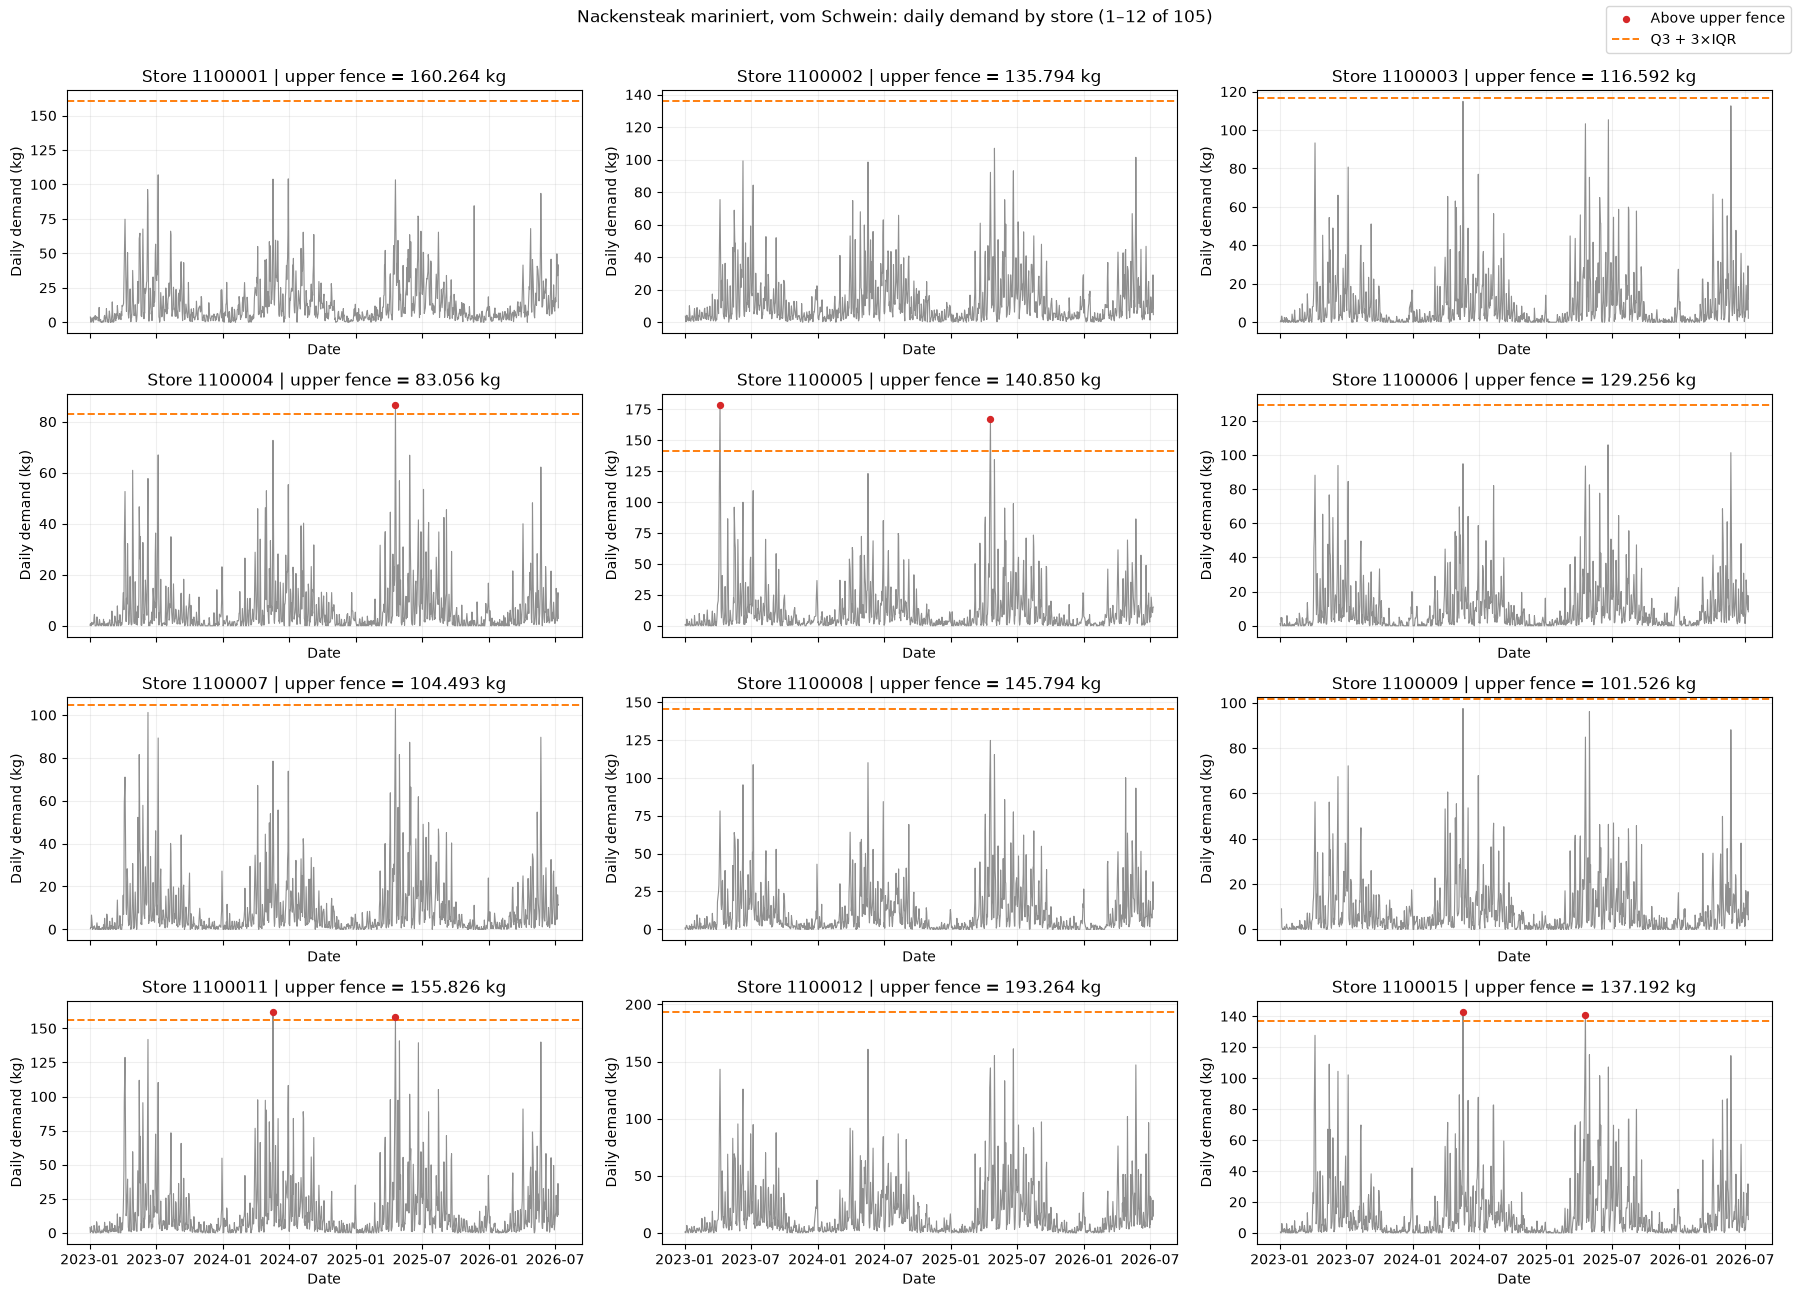

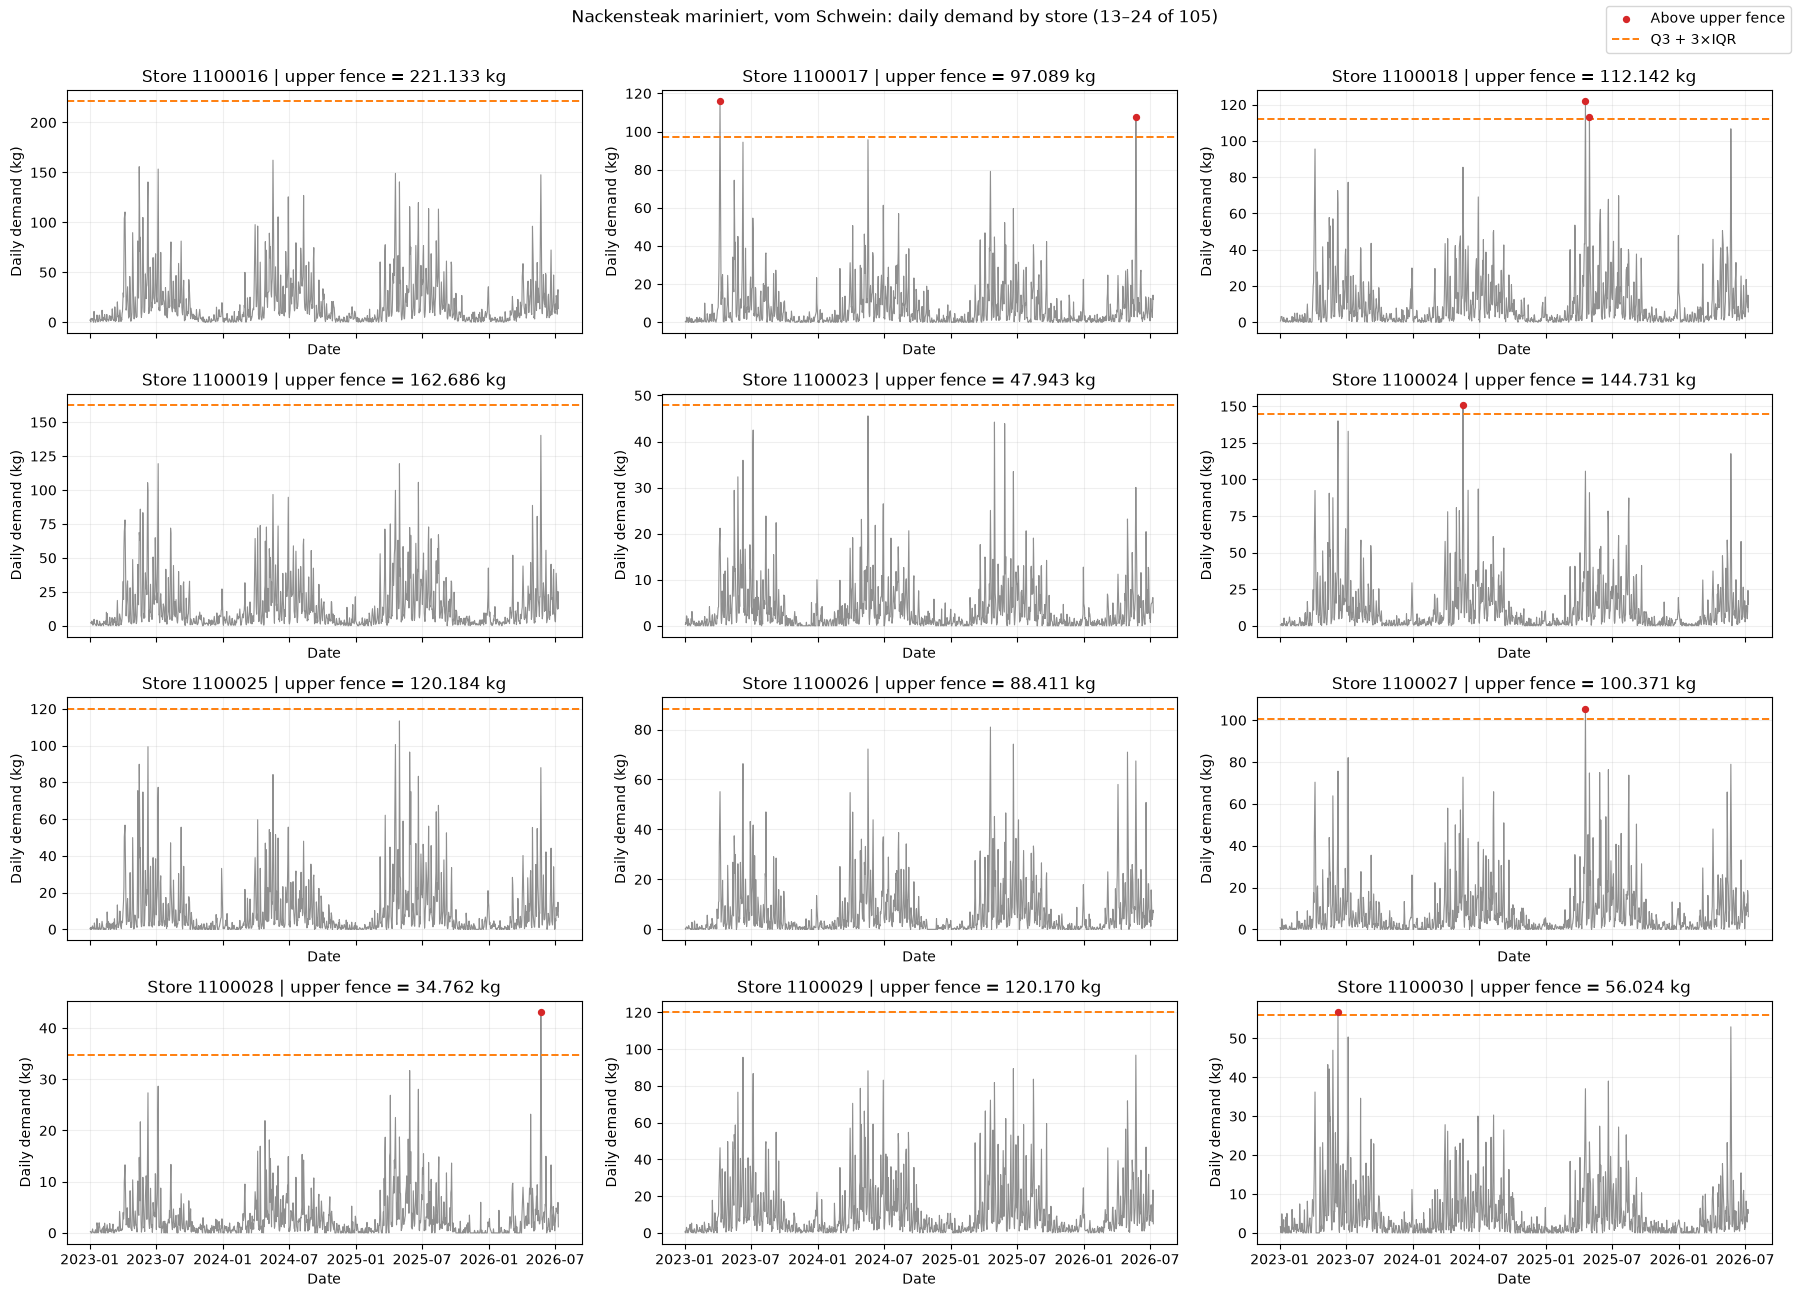

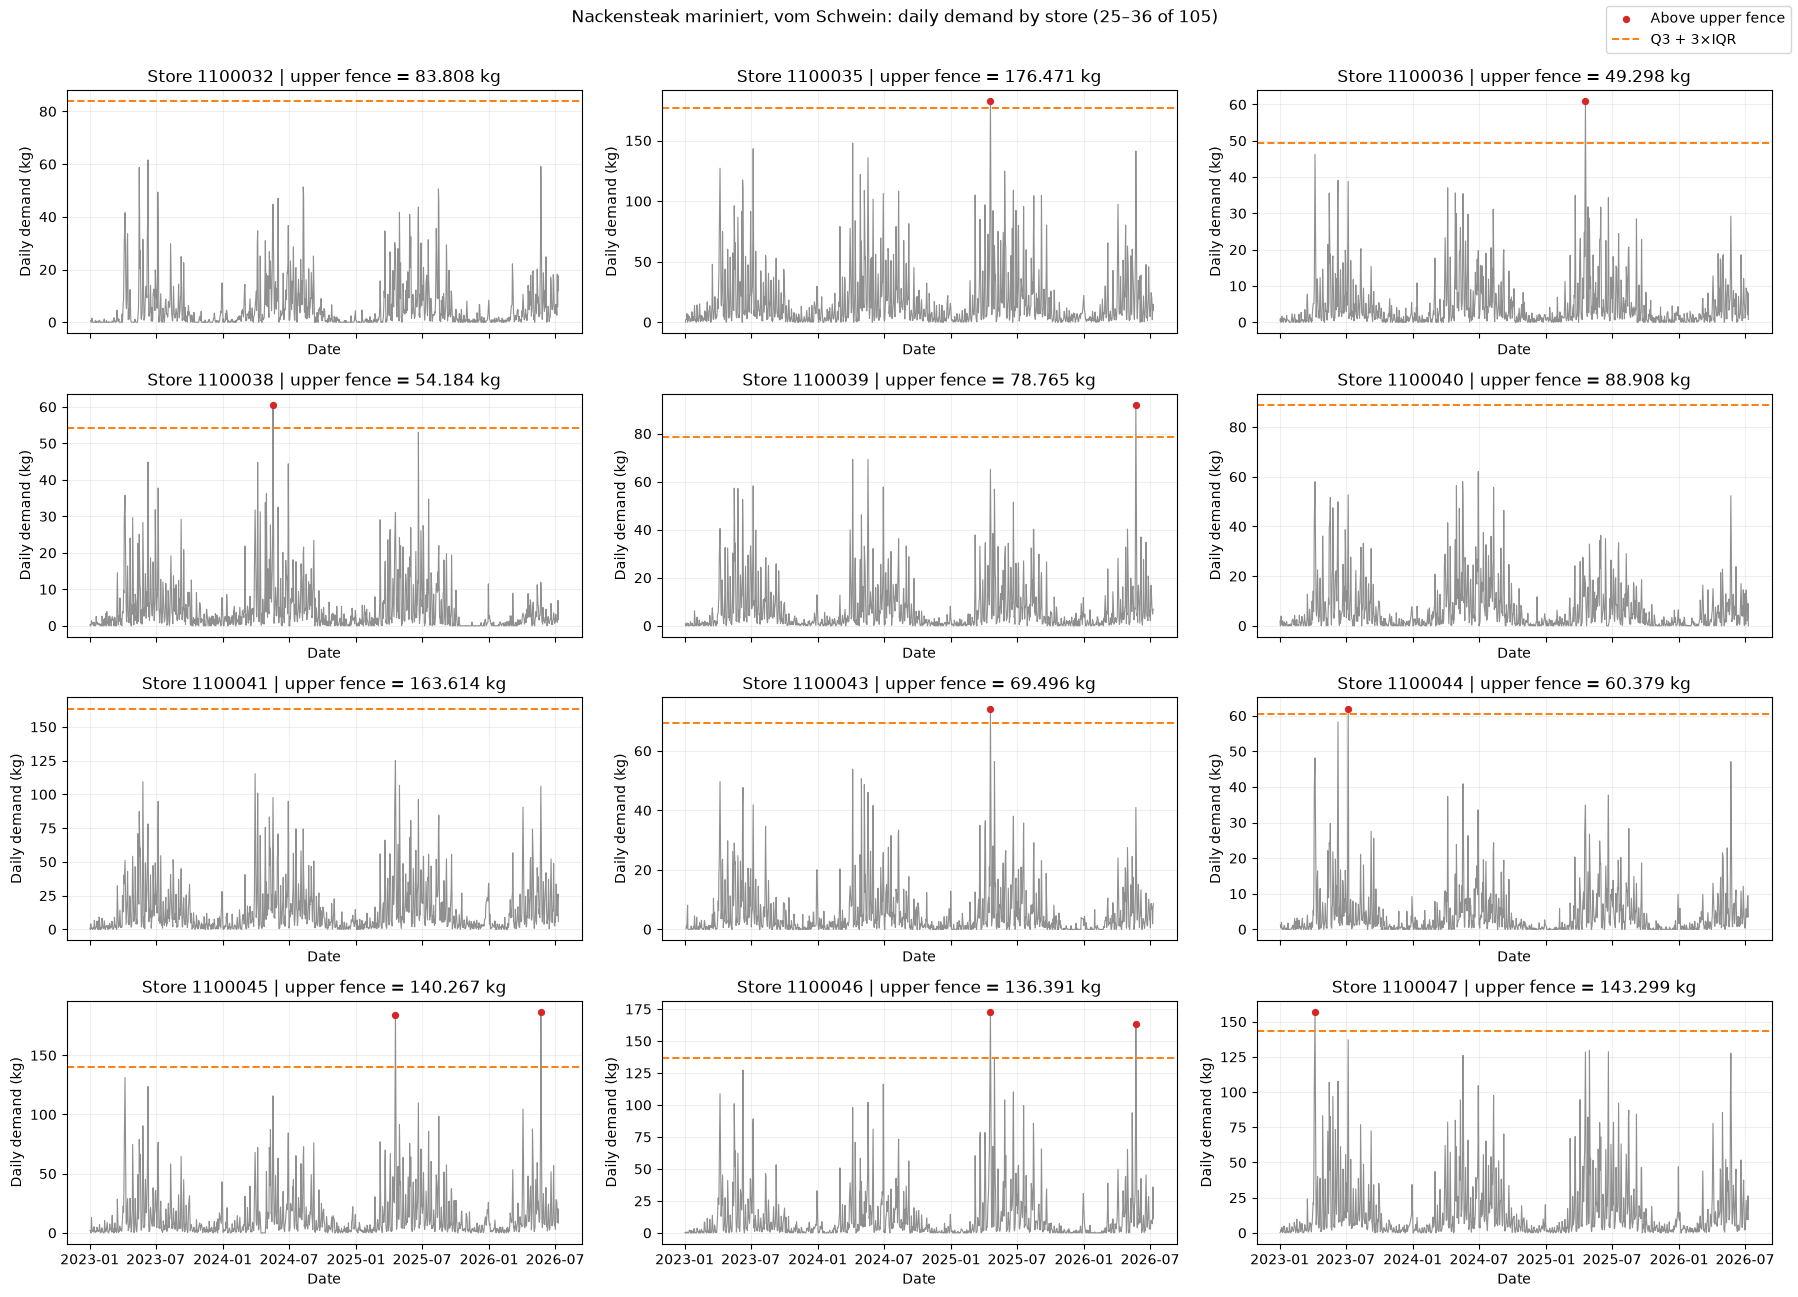

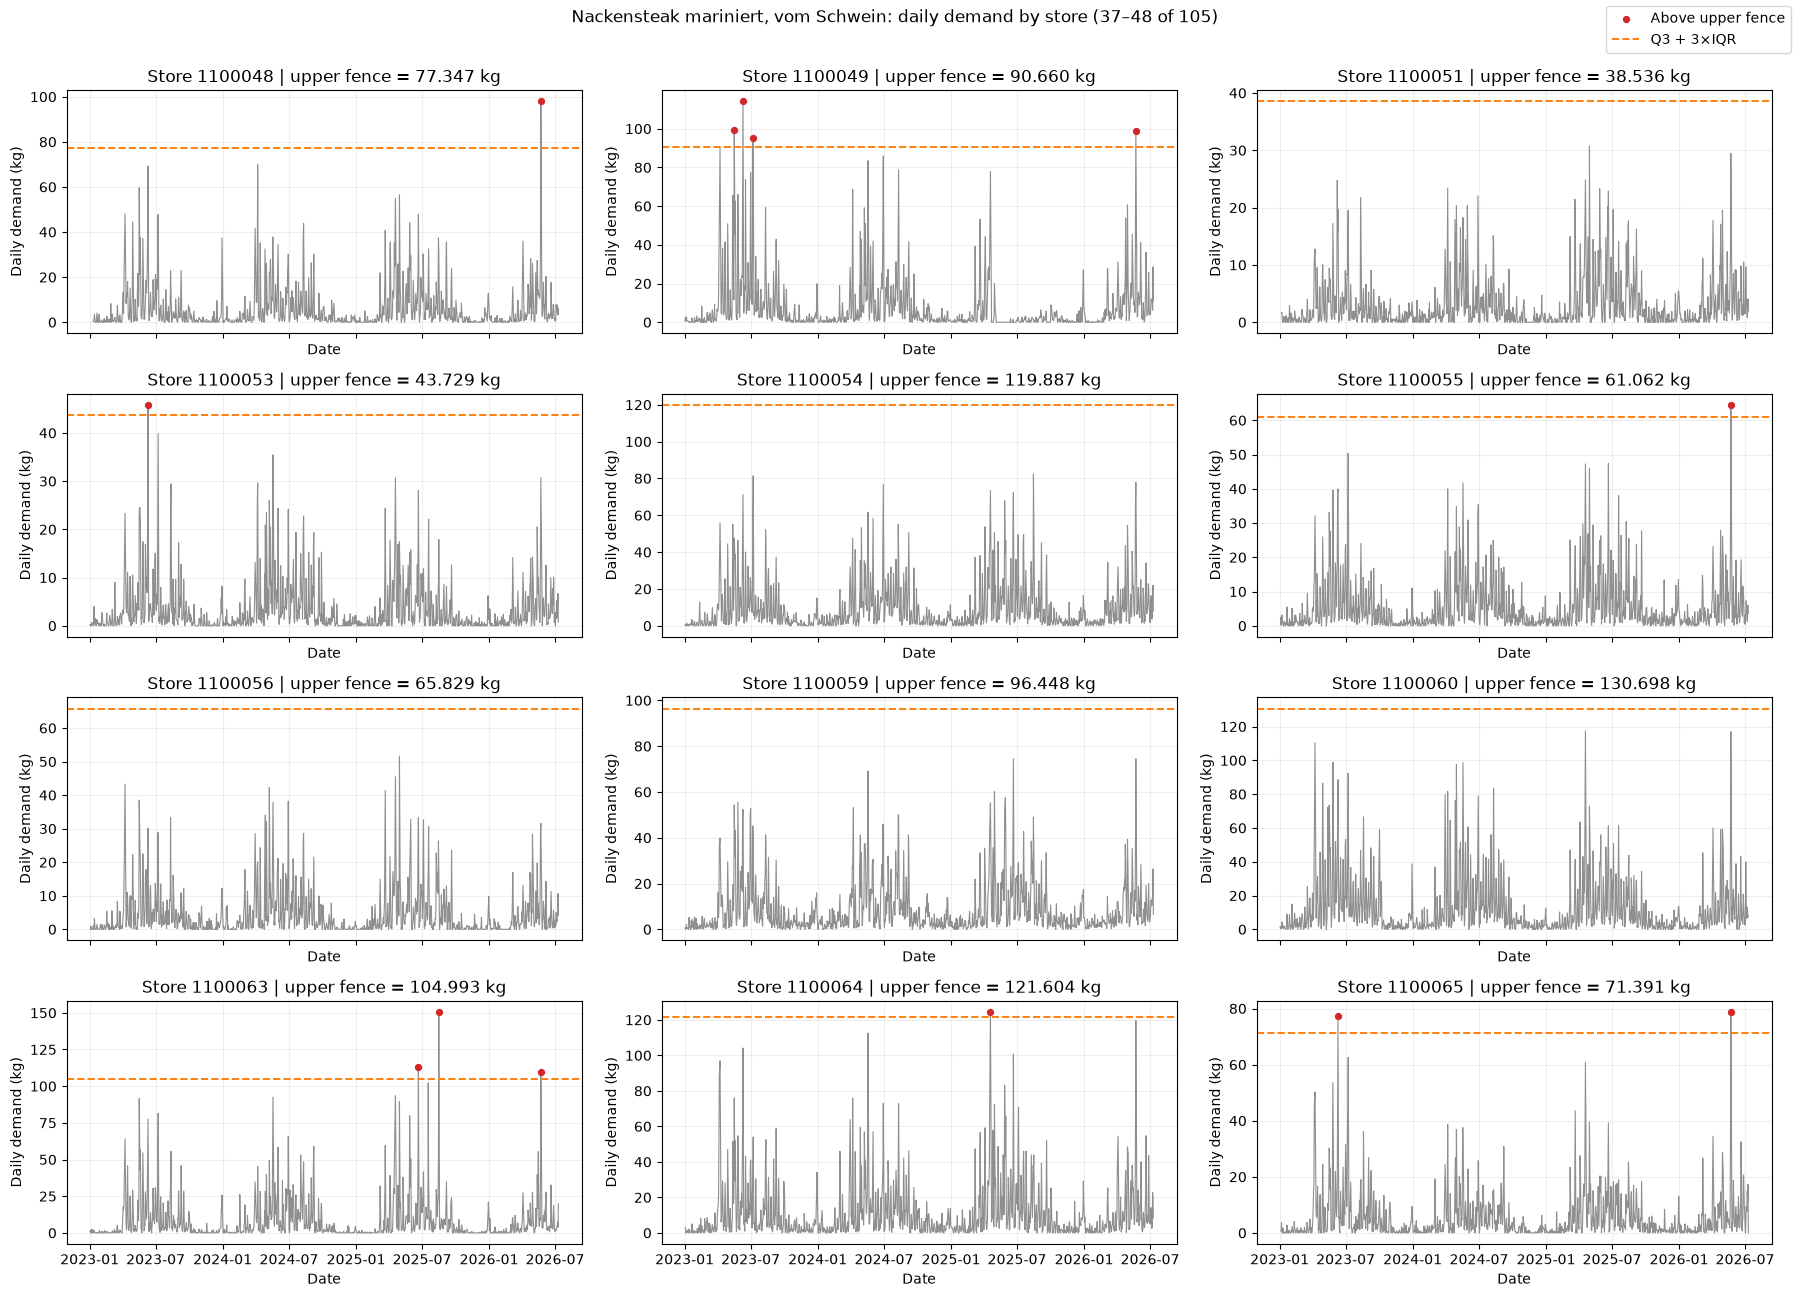

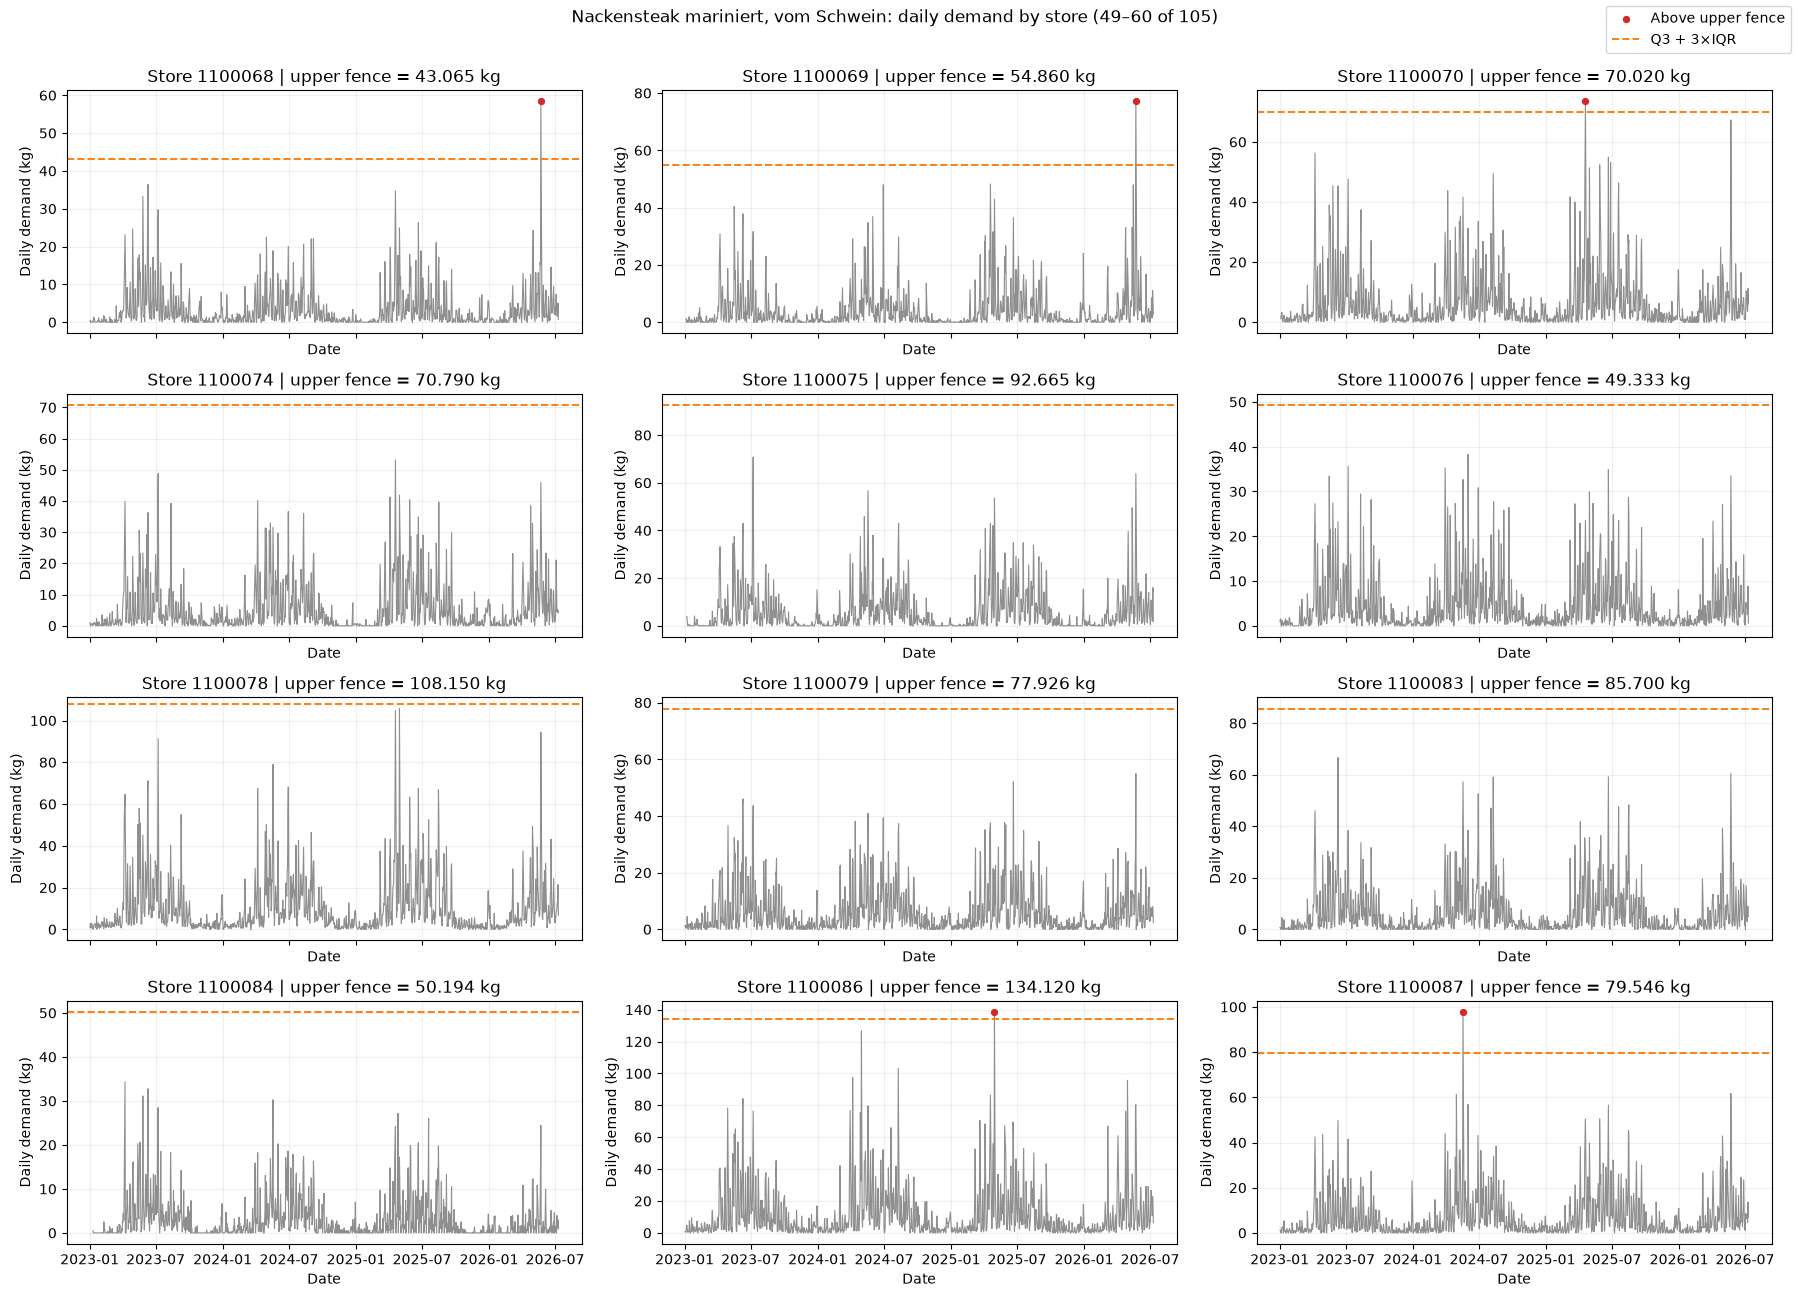

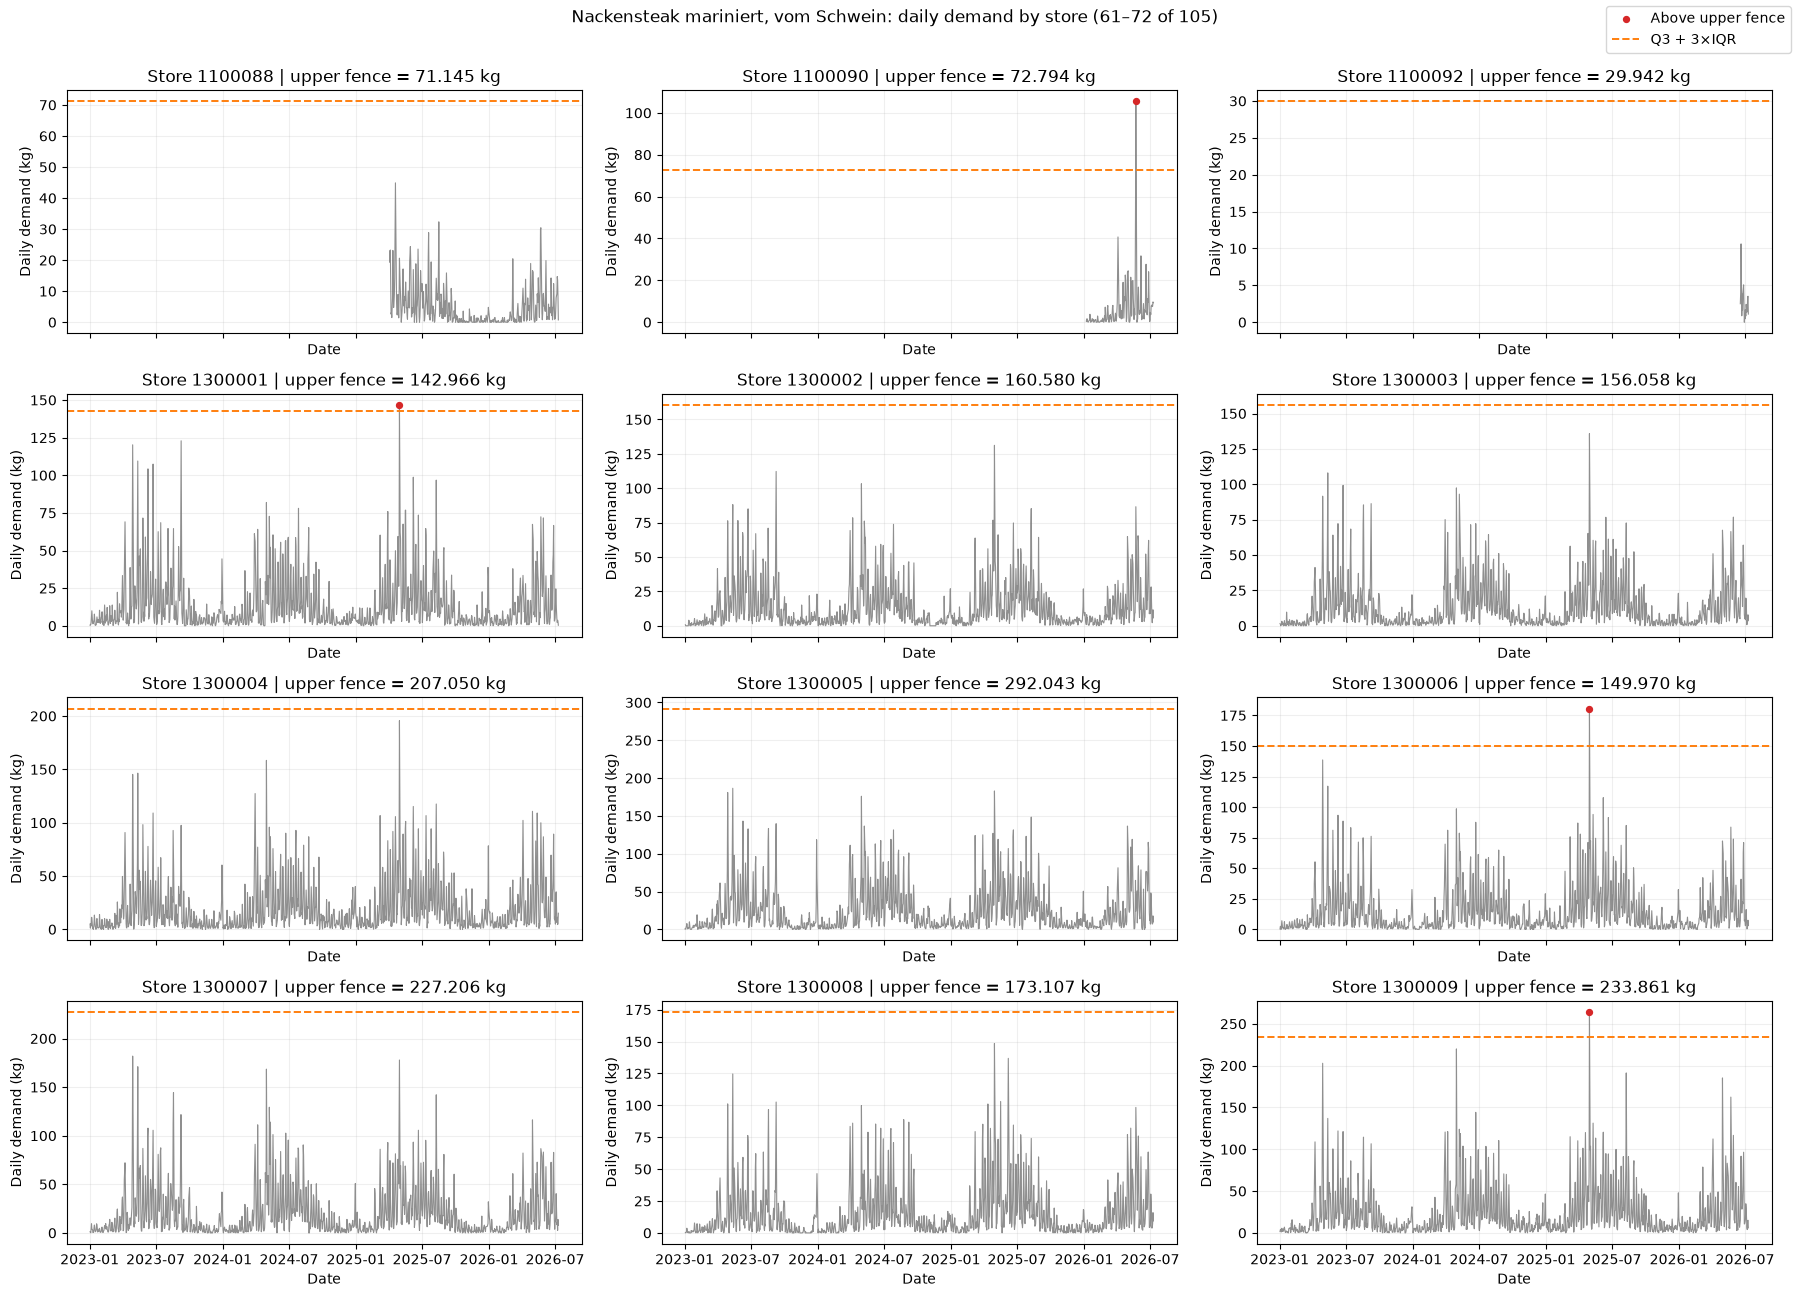

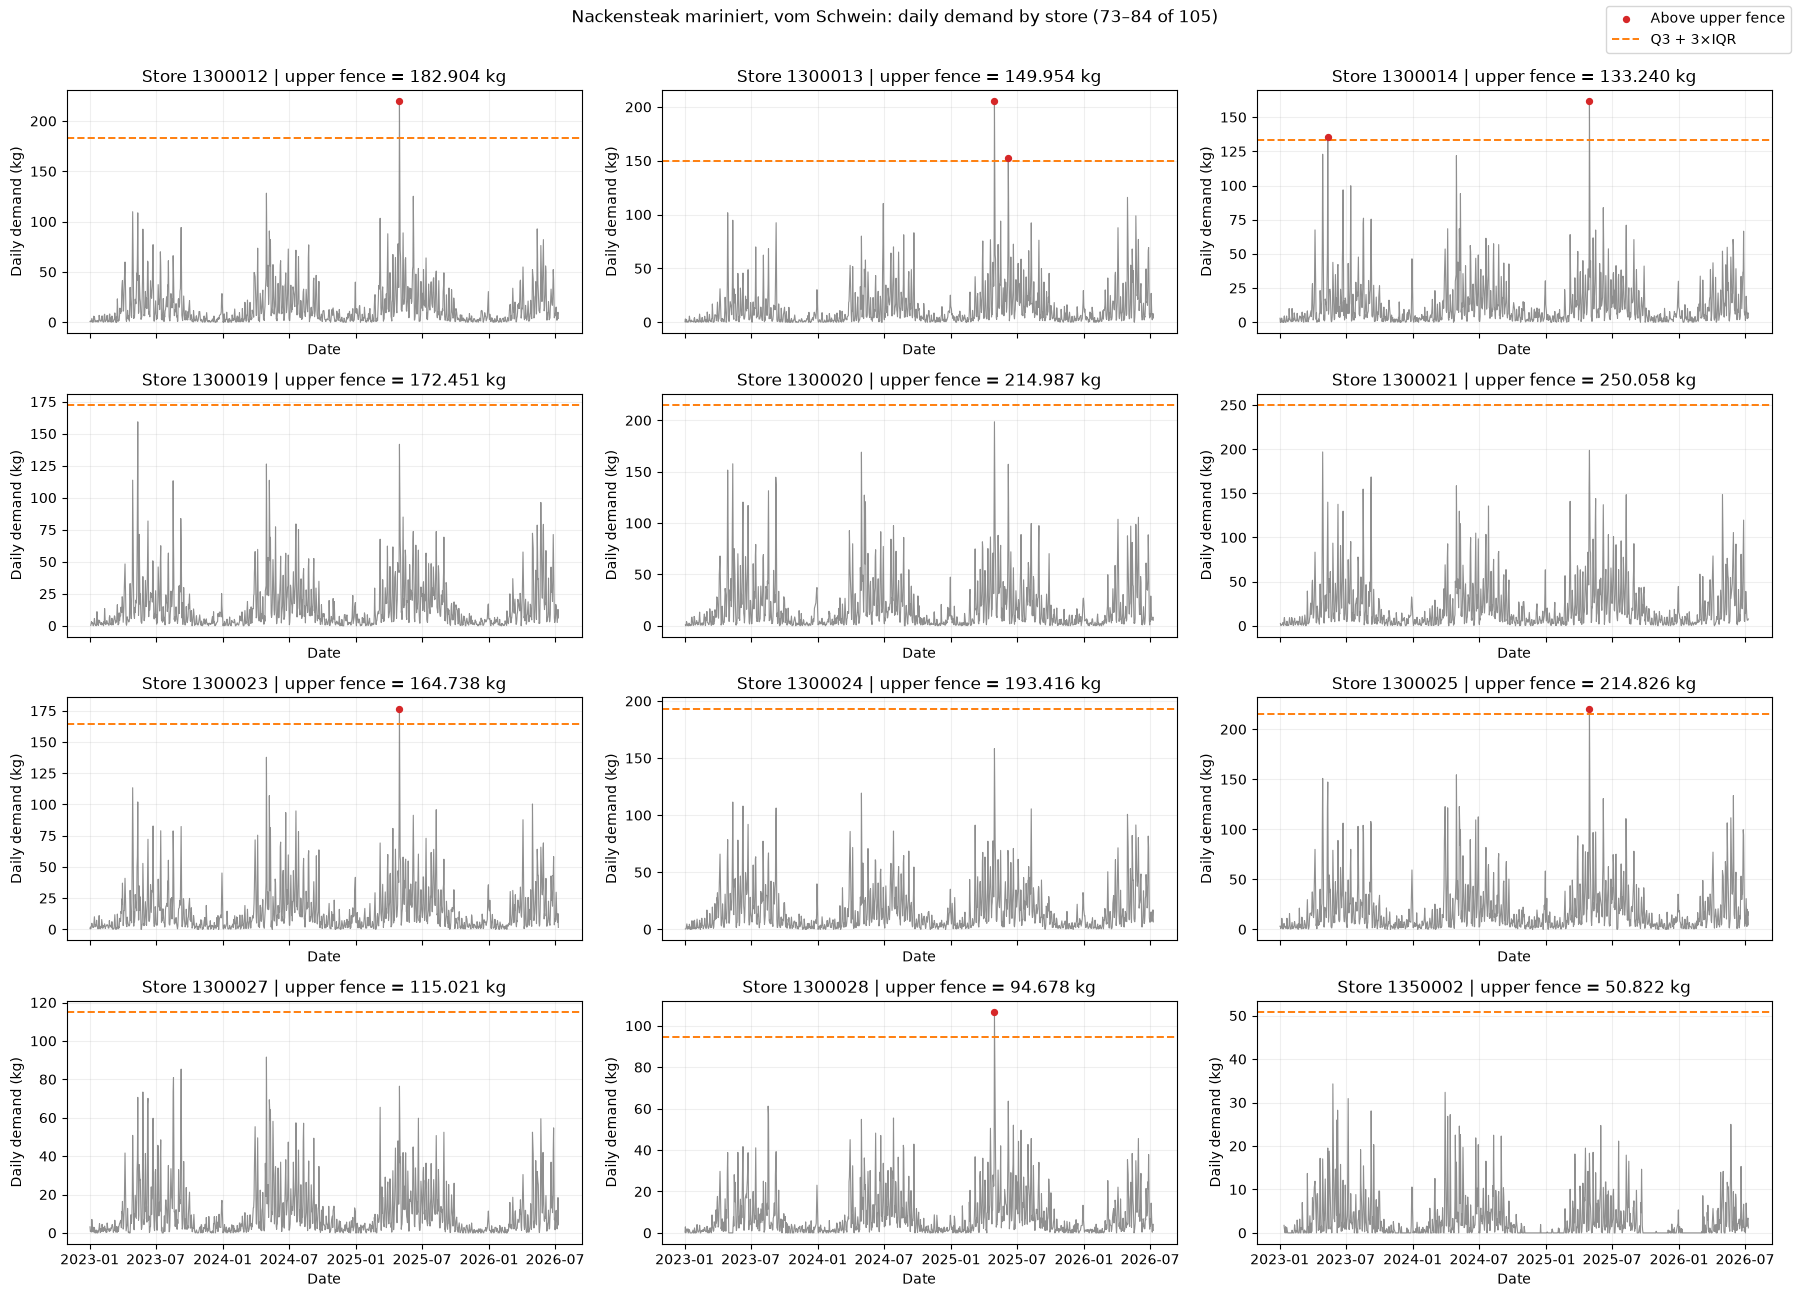

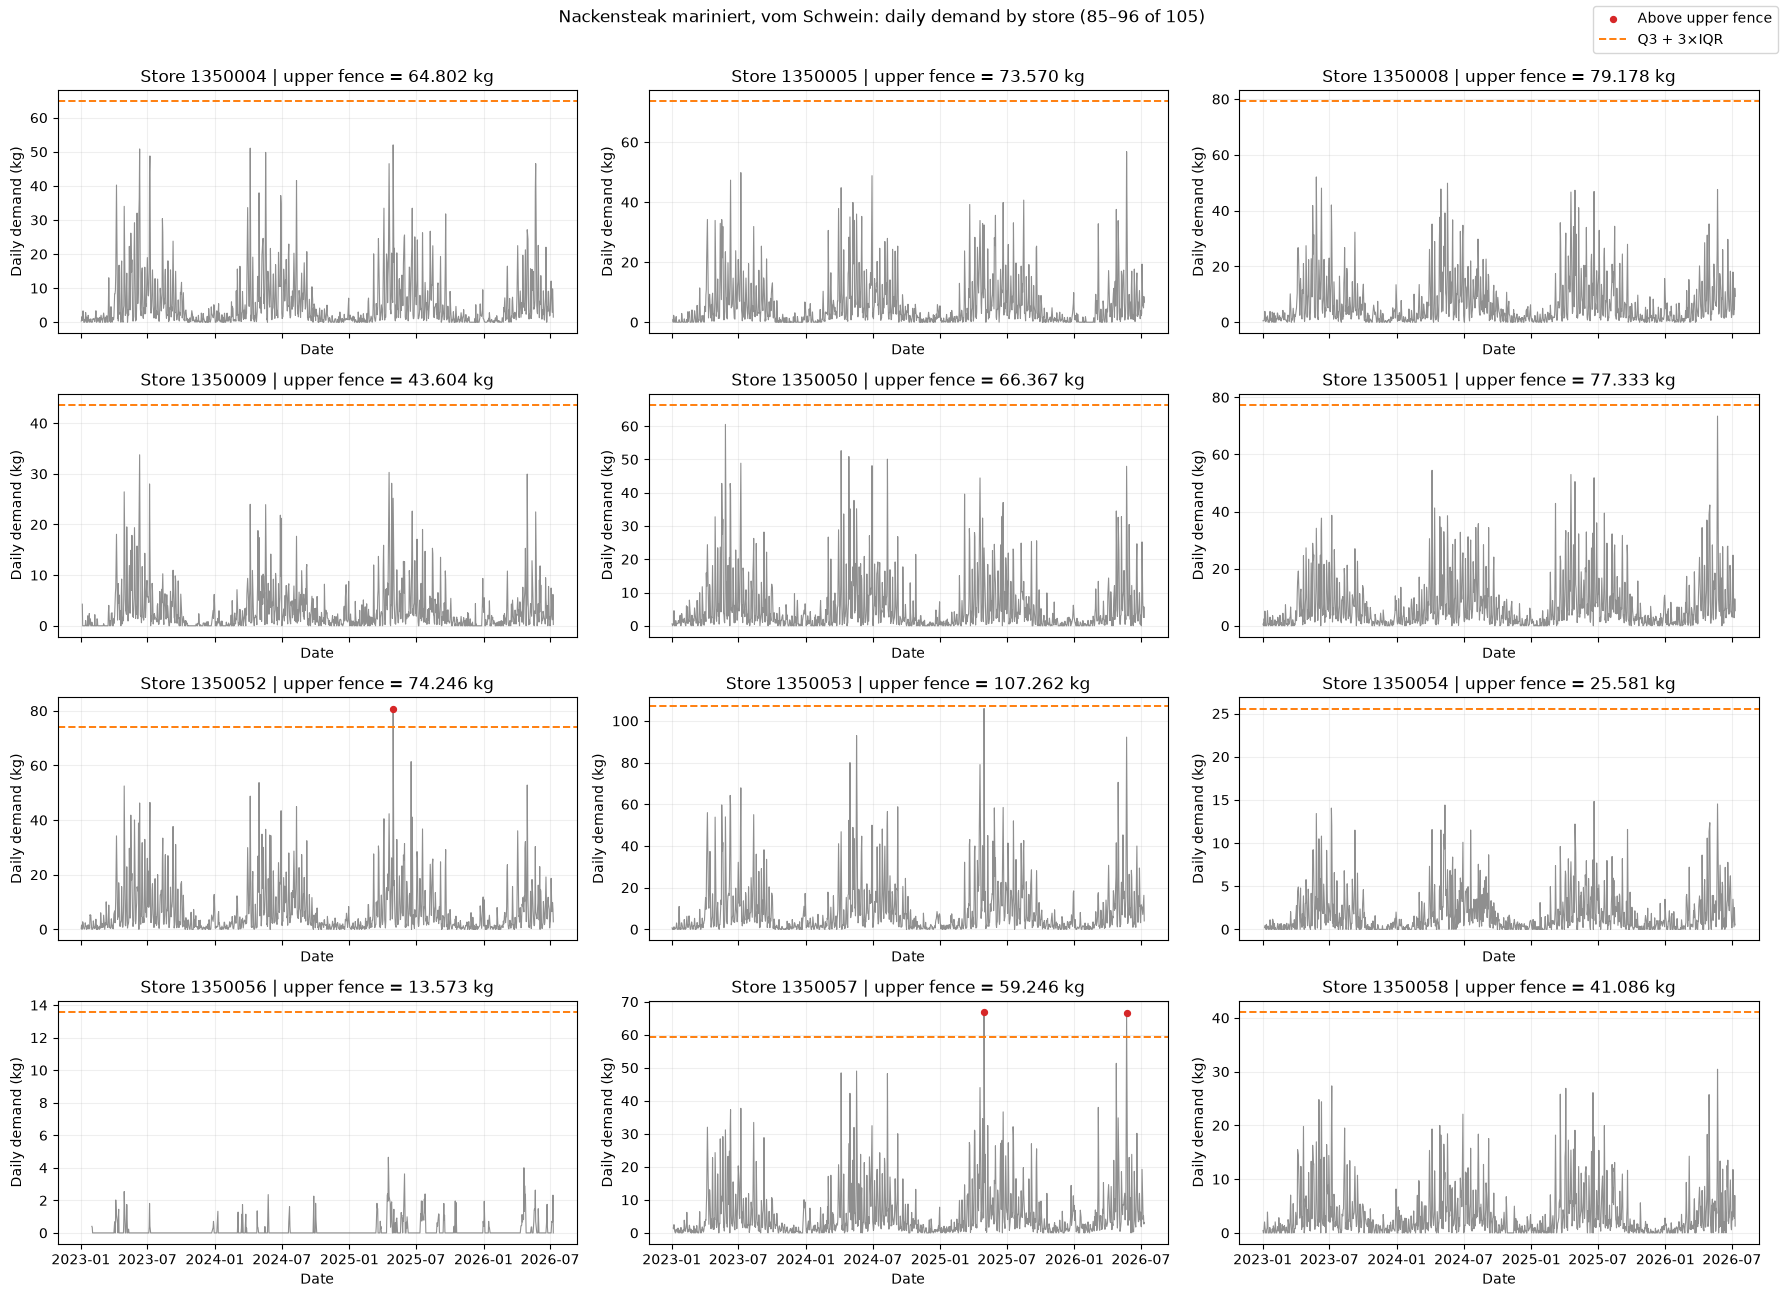

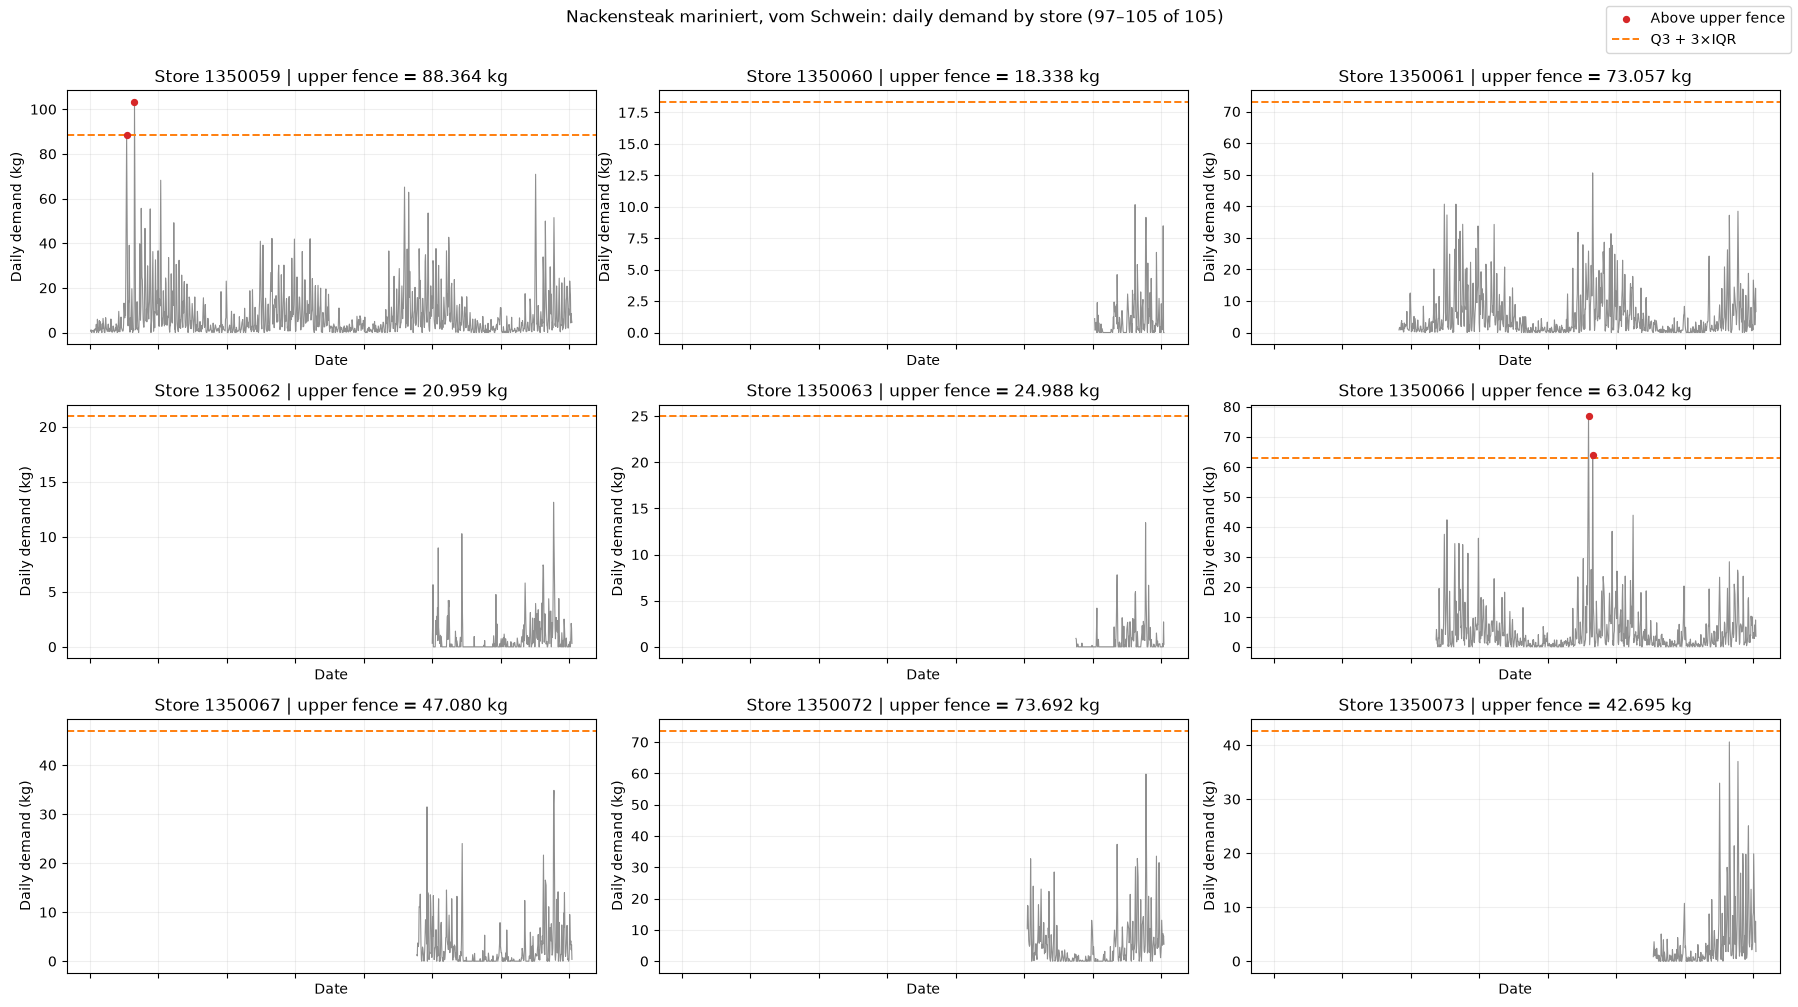

,q1,q3,upper_bound_k3
store_id,,,
1300005,4.20925,30.37600,292.04350
1300021,3.59200,25.99800,250.05800
1300009,4.67350,25.50875,233.86125
1300007,3.20500,23.56875,227.20625
1100016,3.43200,23.22300,221.13300
...,...,...,...
1350054,0.52300,2.80100,25.58100
1350063,0.43350,2.66575,24.98825
1350062,0.42700,2.29350,20.95850


In [11]:
import math

import matplotlib.pyplot as plt
import pandas as pd

PRODUCT_NAME = "Nackensteak mariniert, vom Schwein"
IQR_K = 10.0
STORES_PER_FIGURE = 12
N_COLUMNS = 3

nackensteak = con.execute("""
    SELECT
        DATE::DATE AS date,
        MARKT_ID AS store_id,
        SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg
    FROM read_parquet('../../data/interim/transactions_dst_daily_no_tail/*.parquet')
    WHERE ARTIKEL_BEZ = ?
    GROUP BY DATE, MARKT_ID
    ORDER BY MARKT_ID, DATE
""", [PRODUCT_NAME]).fetchdf()
nackensteak["date"] = pd.to_datetime(nackensteak["date"])

# Match the outlier-removal logic: calculate quartiles from positive daily demand.
positive_demand = nackensteak.loc[nackensteak["demand_kg"] > 0]
store_bounds = (
    positive_demand.groupby("store_id")["demand_kg"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
)
store_bounds["upper_bound_k3"] = (
    store_bounds["q3"] + IQR_K * (store_bounds["q3"] - store_bounds["q1"])
)

store_ids = sorted(store_bounds.index)
n_rows = math.ceil(STORES_PER_FIGURE / N_COLUMNS)

for start in range(0, len(store_ids), STORES_PER_FIGURE):
    page_store_ids = store_ids[start:start + STORES_PER_FIGURE]
    fig, axes = plt.subplots(
        n_rows, N_COLUMNS, figsize=(18, 3.2 * n_rows), sharex=True, squeeze=False
    )

    for ax, store_id in zip(axes.flat, page_store_ids):
        store_data = nackensteak[nackensteak["store_id"] == store_id]
        upper_bound = store_bounds.at[store_id, "upper_bound_k3"]
        above_bound = store_data["demand_kg"] > upper_bound

        ax.plot(
            store_data["date"], store_data["demand_kg"],
            color="0.45", linewidth=0.8, alpha=0.8,
        )
        ax.scatter(
            store_data.loc[above_bound, "date"],
            store_data.loc[above_bound, "demand_kg"],
            color="tab:red", s=18, zorder=3, label="Above upper fence",
        )
        ax.axhline(
            upper_bound, color="tab:orange", linestyle="--", linewidth=1.4,
            label="Q3 + 3×IQR",
        )
        ax.set_title(f"Store {store_id} | upper fence = {upper_bound:.3f} kg")
        ax.set_xlabel("Date")
        ax.set_ylabel("Daily demand (kg)")
        ax.grid(alpha=0.2)

    for ax in axes.flat[len(page_store_ids):]:
        ax.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(
        f"{PRODUCT_NAME}: daily demand by store "
        f"({start + 1}–{start + len(page_store_ids)} of {len(store_ids)})",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()

store_bounds.sort_values("upper_bound_k3", ascending=False)
